# What does your voice look like?

### Package Installation

This cell installs the external libraries required for the lab. The `!` symbol allows terminal commands such as `pip install` to be run directly inside a Jupyter Notebook cell. These packages provide tools for working with the OpenAI API, recording audio, processing sound files, and analysing audio data.

In [1]:
!pip install openai pydub
!pip install sounddevice
!pip install librosa



### Library Imports

This cell imports the libraries and functions needed for the speech-to-text workflow. These imports provide tools for handling WAV audio files, working with the OpenAI Whisper API, managing environment variables securely, processing in-memory audio data, and playing audio back inside the Jupyter Notebook.

### API Key Validation

This code checks whether the OpenAI API key was successfully loaded from the environment variables. If no key is found (`None`), the program raises an error to stop execution before attempting to use the Whisper API.

In [2]:
import sounddevice as sd
import os
import io
import numpy as np
import librosa
import librosa.display
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import scipy.io.wavfile as wavfile
from openai import OpenAI
from dotenv import load_dotenv
load_dotenv()

if os.getenv("OPENAI_API_KEY") is None:
    raise ValueError("API key not loaded")

### Audio Recording and Visualisation

This cell records audio from the microphone and stores it as numerical audio data using NumPy arrays. It then visualises the recording in three different ways: a waveform showing amplitude over time, a mel spectrogram representing speech frequencies in a human-like way, and a frequency spectrogram showing the intensity of frequencies throughout the recording.

### Audio Recording

This code records audio from the microphone using the `sounddevice` library. The recording is stored in the `audio` variable as numerical sample data, while parameters such as sample rate, number of channels, and data type control the quality and format of the recording.

The total number of audio samples is calculated by multiplying the recording duration by the sample rate.

🎤 Recording for 5 seconds... Speak now!
✅ Recording complete!
This is your voice
Mel Spectogram
Spectogram


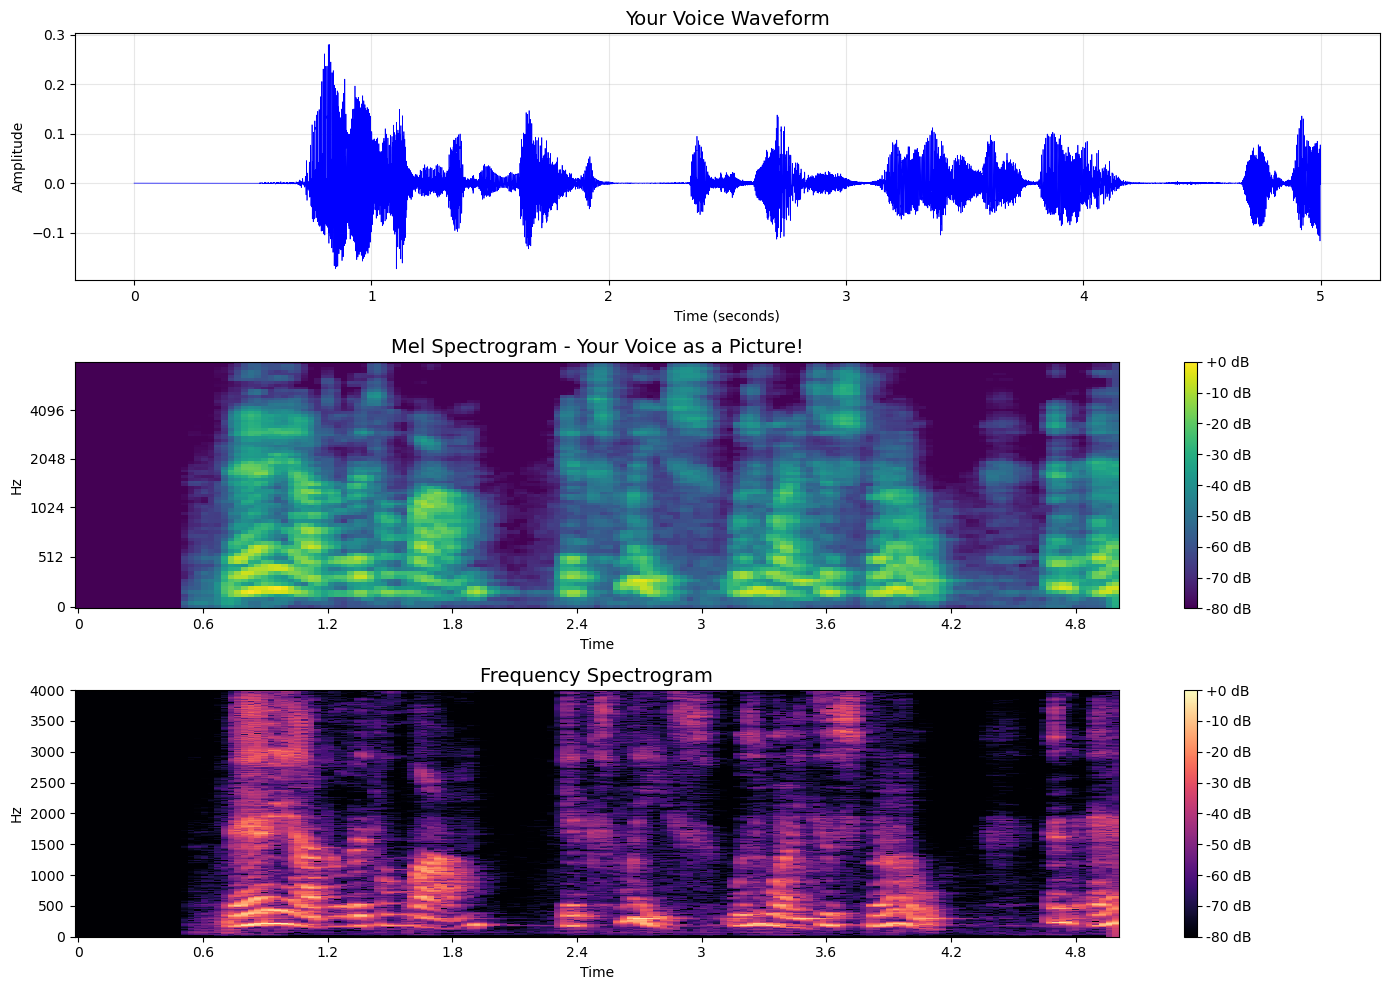

In [3]:



duration = 5  # seconds
sample_rate = 16000

print(f"🎤 Recording for {duration} seconds... Speak now!")
audio = sd.rec(int(duration * sample_rate), 
               samplerate=sample_rate, 
               channels=1, 
               dtype='float32')
sd.wait()
audio = audio.flatten()
print("✅ Recording complete!")


print("This is your voice")
fig, axes = plt.subplots(3, 1, figsize=(14, 10))

time = np.linspace(0, len(audio) / sample_rate, len(audio))
axes[0].plot(time, audio, color='blue', linewidth=0.5)
axes[0].set_title('Your Voice Waveform', fontsize=14)
axes[0].set_xlabel('Time (seconds)')
axes[0].set_ylabel('Amplitude')
axes[0].grid(True, alpha=0.3)

print("Mel Spectogram") 
mel_spec = librosa.feature.melspectrogram(y=audio, sr=sample_rate, n_mels=80)
mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
img = librosa.display.specshow(mel_spec_db, sr=sample_rate, 
                                x_axis='time', y_axis='mel', 
                                ax=axes[1], cmap='viridis')
axes[1].set_title('Mel Spectrogram - Your Voice as a Picture!', fontsize=14)
plt.colorbar(img, ax=axes[1], format='%+2.0f dB')

print("Spectogram") 
D = librosa.stft(audio)
D_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)
img2 = librosa.display.specshow(D_db, sr=sample_rate, 
                                 x_axis='time', y_axis='hz', 
                                 ax=axes[2], cmap='magma')
axes[2].set_title('Frequency Spectrogram', fontsize=14)
axes[2].set_ylim(0, 4000)  # Focus on speech frequencies
plt.colorbar(img2, ax=axes[2], format='%+2.0f dB')

plt.tight_layout()
plt.show()

### Audio Playback

This code uses IPython's `Audio` function to play back the recorded audio directly inside the Jupyter Notebook. The sample rate is provided so the audio is played at the correct speed and pitch.

In [4]:
from IPython.display import Audio
Audio(audio, rate=sample_rate)

### Saving the Audio File

This code saves the recorded audio as a WAV file inside the `audio` folder. The audio data is converted to `int16` format because WAV files commonly use integer-based sample values for compatibility with standard audio software and APIs.

Saving the audio file makes the recording persistent, so it can be reused, reviewed, submitted, or processed again after the notebook session ends.

In [5]:
audio_int16 = np.int16(audio * 32767)
wavfile.write("audio/recording.wav", sample_rate, audio_int16)

### Inspecting Audio Data

This code checks the structure of the recorded audio data. `type(audio)` confirms that the recording is stored as a NumPy array, while `audio.shape` shows the size and dimensions of the audio sample data.

In [6]:
print(type(audio))
print(audio.shape)

<class 'numpy.ndarray'>
(80000,)


# Whisper API

### Whisper API Transcription

This cell records a short audio clip, converts it into WAV-compatible audio data, and sends it to the OpenAI Whisper API for speech-to-text transcription. The returned transcription text is then displayed in the notebook.

In [7]:
load_dotenv(override=True)

client = OpenAI(api_key=os.getenv("OPENAI_API_KEY"))

duration = 5  # seconds
sample_rate = 16000

print(f"🎤 Recording for {duration} seconds... Speak now!")
audio = sd.rec(int(duration * sample_rate), 
               samplerate=sample_rate, 
               channels=1, 
               dtype='float32')
sd.wait()
audio = audio.flatten()
print("✅ Recording complete!")


audio_int16 = np.int16(audio * 32767)

# Create in-memory WAV file
buffer = io.BytesIO()
wavfile.write(buffer, sample_rate, audio_int16)
buffer.seek(0)
buffer.name = "recording.wav"  # Whisper needs a filename

# Transcribe with Whisper
print("🤖 Transcribing with Whisper...")
transcript = client.audio.transcriptions.create(
    model="whisper-1",
    file=buffer
)

print("\n📝 Transcription:")
print("-" * 40)
print(transcript.text)

🎤 Recording for 5 seconds... Speak now!
✅ Recording complete!
🤖 Transcribing with Whisper...

📝 Transcription:
----------------------------------------
Mary had a little lamb, its fleece was white as snow,


# Super Power: Context

### Unguided Whisper Transcription Test

This section tests Whisper's transcription accuracy using a longer scripted reading passage containing ambiguous words, technical terms, numbers, and accented names. The audio is transcribed without providing contextual prompts, allowing the model's natural speech recognition capabilities to be evaluated.

In [8]:
from IPython.display import Audio, display, Markdown

# Display a 30-second reading text
reading_text = """
**Read this text aloud (about 30 seconds):**

The researchers' analyses of the wind farm data showed variable wind patterns. The project 
lead will lead the team through complex permit processes. They must present the present 
findings to investors. The 3 million contract includes clauses for force majeure 
events. Dr. García-Smith's team discovered that the enzyme's pH of 7.2 was optimal. The 
AI learned to differentiate between "read" (present) and "read" (past), processing live 
feeds versus archived content. The baroque bass player stood close to the entrance, too 
close to record properly.
"""

display(Markdown(reading_text))

# Record for 30 seconds
duration = 45
sample_rate = 16000

print(f"\n🎤 Recording for {duration} seconds... Start reading now!")
audio = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1, dtype='float32')
sd.wait()
audio = audio.flatten()
print("✅ Recording complete!")

display(Audio(audio, rate=sample_rate))


# Prepare audio
audio_int16 = np.int16(audio * 32767)
buffer = io.BytesIO()
wavfile.write(buffer, sample_rate, audio_int16)
buffer.seek(0)
buffer.name = "recording.wav"

# Transcribe without context prompt
print("🤖 Transcribing without context...")
transcript = client.audio.transcriptions.create(
    model="whisper-1",
    file=buffer,
)

print("\n📝 Transcription:")
print("-" * 40)
print(transcript.text)


**Read this text aloud (about 30 seconds):**

The researchers' analyses of the wind farm data showed variable wind patterns. The project 
lead will lead the team through complex permit processes. They must present the present 
findings to investors. The 3 million contract includes clauses for force majeure 
events. Dr. García-Smith's team discovered that the enzyme's pH of 7.2 was optimal. The 
AI learned to differentiate between "read" (present) and "read" (past), processing live 
feeds versus archived content. The baroque bass player stood close to the entrance, too 
close to record properly.



🎤 Recording for 45 seconds... Start reading now!
✅ Recording complete!


🤖 Transcribing without context...

📝 Transcription:
----------------------------------------
The researchers' analyses of the wind farm data showed variable wind patterns. The project lead will lead the team through complex permit processes. They must present the present findings to investors. The 3 million contract includes clauses for force majeure events. Dr. Garcia Smith's team discovered that the enzyme's pH of 7.2 was optimal. The AI learned to differentiate between read, present, and read, past, processing live feeds versus archived content. The Baroque bass player stood close to the entrance, too close to record properly.


### Guided Whisper Transcription

This section performs transcription using a contextual prompt to guide the Whisper model. The prompt contains ambiguous words, technical vocabulary, and names from the reading passage, helping improve transcription accuracy by giving the model additional context before processing the audio.

In [9]:

# Transcribe with context prompt
print("🤖 Transcribing with context...")
transcript = client.audio.transcriptions.create(
    model="whisper-1",
    file=buffer,
    prompt = "heteronyms, homographs, lead metal, wind turbine, present tense, past tense read, pH levels, enzyme, García-Smith, force majeure, baroque, bass instrument, differentiate")

print("\n📝 Transcription:")
print("-" * 40)
print(transcript.text)

🤖 Transcribing with context...

📝 Transcription:
----------------------------------------
Yn ystafellau'r ymgeisyddion o'r data o'r windfarn, roedd yn dangos patternau ffyrdd gwahanol i'r wind. Bydd y cyfarwyddwr y prosiect yn ymgyrchu'r tîm trwy prosesau permi'r complex. Mae'n rhaid iddyn nhw gyflwyno'r cyflwynoedd sydd ar gael i'r fuddsoddiadur. Mae'r contract o £3 miliwn yn cynnwys cyfrifiadurau ar gyfer ymgeisyddiaethau force majeure. Y tîm o Dr. García-Smith ysgrifennodd bod y pH o'r enzymau 7.2 yn optimol. Dysgu i'r cyfarwyddwr gwahanol rhwng ysgrifennu, cyfnod, ac ysgrifennu. Ymgyrchu ffyrdd gwahanol ynghylch gynlluniau archif. Roedd y chwaraewr baroque bas yn ystod yn dda i'r ffwrdd. Mae'n dda iawn i'w recordio.


### Audio Chunking and Batch Transcription

This section demonstrates audio chunking for longer recordings. The recorded audio is split into smaller segments that can be processed individually by the Whisper API, helping manage longer audio files more efficiently before combining the transcriptions into one final result.


# Chunking

In [10]:
# Record longer audio
duration = 15  # seconds total
sample_rate = 16000
chunk_duration = 5  # seconds per chunk

print(f"🎤 Recording for {duration} seconds... Speak continuously!")
audio = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1, dtype='float32')
sd.wait()
audio = audio.flatten()
print("✅ Recording complete!")

display(Audio(audio, rate=sample_rate))


# Split audio into chunks
chunk_size = chunk_duration * sample_rate
chunks = [audio[i:i+chunk_size] for i in range(0, len(audio), chunk_size)]

print(f"\n🔪 Split into {len(chunks)} chunks")

# Transcribe each chunk
all_transcripts = []

for i, chunk in enumerate(chunks):
    print(f"\n🤖 Transcribing chunk {i+1}/{len(chunks)}...")
    
    # Prepare chunk buffer
    chunk_int16 = np.int16(chunk * 32767)
    buffer = io.BytesIO()
    wavfile.write(buffer, sample_rate, chunk_int16)
    buffer.seek(0)
    buffer.name = f"chunk_{i}.wav"
    
    # Transcribe
    transcript = client.audio.transcriptions.create(
        model="whisper-1",
        file=buffer
    )
    
    all_transcripts.append(transcript.text)
    print(f"Chunk {i+1}: {transcript.text}")

# Combine all transcripts
print("\n📝 Complete Transcription:")
print("-" * 40)
full_text = " ".join(all_transcripts)
print(full_text)

🎤 Recording for 15 seconds... Speak continuously!
✅ Recording complete!



🔪 Split into 3 chunks

🤖 Transcribing chunk 1/3...
Chunk 1: Diolch yn fawr iawn.

🤖 Transcribing chunk 2/3...
Chunk 2: for 15 seconds it apparently seems to be. I don't know why but...

🤖 Transcribing chunk 3/3...
Chunk 3: We can talk for 15 seconds, no problem. I can speak for hours if we want.

📝 Complete Transcription:
----------------------------------------
Diolch yn fawr iawn. for 15 seconds it apparently seems to be. I don't know why but... We can talk for 15 seconds, no problem. I can speak for hours if we want.


### Saving Audio Chunks

This line saves each processed audio chunk as a separate WAV file inside the `chunks` folder. An f-string is used to dynamically generate unique filenames for each chunk during the loop.

In [11]:
wavfile.write(f"chunks/chunk_{i}.wav", sample_rate, chunk_int16)

# Time Stamps

### Timestamped Whisper Transcription

This section performs a detailed Whisper transcription using the `verbose_json` response format to extract timestamp information alongside the text. Segment timestamps make the transcription easier to navigate, search, subtitle, and reference by showing when each section of speech occurred in the audio recording.

In [12]:
duration = 10  # seconds
sample_rate = 16000

print(f"🎤 Recording for {duration} seconds... Speak with pauses!")
audio = sd.rec(int(duration * sample_rate), samplerate=sample_rate, channels=1, dtype='float32')
sd.wait()
audio = audio.flatten()
print("✅ Recording complete!")

# Play back
display(Audio(audio, rate=sample_rate))

# Prepare audio
audio_int16 = np.int16(audio * 32767)
buffer = io.BytesIO()
wavfile.write(buffer, sample_rate, audio_int16)
buffer.seek(0)
buffer.name = "recording.wav"

# Get detailed transcription with timestamps
print("\n🤖 Transcribing with timestamps...")
transcript = client.audio.transcriptions.create(
    model="whisper-1",
    file=buffer,
    response_format="verbose_json",
    timestamp_granularities=["segment", "word"]  # Get both segment and word timestamps
)

# Display formatted timestamps
print("\n📝 Transcription with timestamps:")
print("-" * 40)

# Show segments with timestamps
if hasattr(transcript, 'segments'):
    for segment in transcript.segments:
        start = segment.start
        end = segment.end
        text = segment.text
        print(f"\n[{start:.2f}s - {end:.2f}s]")
        print(f"  {text}")

# # Show word-level timestamps if available
# if hasattr(transcript, 'words'):
#     print("\n🔤 Word-level timing:")
#     print("-" * 40)
#     for word in transcript.words:
#         word_text = word.word
#         start = word.start
#         end = word.end
#         print(f"{word_text:15} [{start:.2f}s - {end:.2f}s]")

# Full text and metadata
print("\n📄 Full text:")
print(transcript.text)

print(f"\n🌍 Language detected: {transcript.language}")
print(f"⏱️ Total duration: {transcript.duration:.2f}s")

🎤 Recording for 10 seconds... Speak with pauses!
✅ Recording complete!



🤖 Transcribing with timestamps...

📝 Transcription with timestamps:
----------------------------------------

[1.56s - 6.28s]
   I've got to speak for another 10 seconds without any pauses, I'm not going to speak that long.

[6.66s - 9.42s]
   I'm going to speak for a little bit, but I'm not going to speak too long.

📄 Full text:
I've got to speak for another 10 seconds without any pauses, I'm not going to speak that long. I'm going to speak for a little bit, but I'm not going to speak too long.

🌍 Language detected: english
⏱️ Total duration: 10.00s


### Inspecting Transcription Segments

This code extracts the transcription segments returned by Whisper and checks how many segments were generated from the audio recording. Each segment contains a portion of transcribed speech along with timestamp information.

In [13]:
segments = transcript.segments
print(len(segments))

2


### Inspecting a Segment Object

This line prints the first transcription segment returned by Whisper. It is used to inspect the structure of the segment object, including fields such as the transcribed text and timestamp metadata.

In [14]:
print(segments[0])

TranscriptionSegment(id=0, avg_logprob=-0.34210336208343506, compression_ratio=1.541284441947937, end=6.28000020980835, no_speech_prob=0.36011338233947754, seek=0, start=1.559999942779541, temperature=0.0, text=" I've got to speak for another 10 seconds without any pauses, I'm not going to speak that long.", tokens=[50364, 286, 600, 658, 281, 1710, 337, 1071, 1266, 3949, 1553, 604, 2502, 8355, 11, 286, 478, 406, 516, 281, 1710, 300, 938, 13, 50680])


### Displaying Formatted Timestamps

This loop iterates through each transcription segment and prints the start time, end time, and transcribed text in a readable format. The `:.2f` formatting limits the timestamp values to two decimal places for cleaner output.

In [15]:
for segment in segments:
    print(f"[{segment.start:.2f}s - {segment.end:.2f}s] {segment.text}")

[1.56s - 6.28s]  I've got to speak for another 10 seconds without any pauses, I'm not going to speak that long.
[6.66s - 9.42s]  I'm going to speak for a little bit, but I'm not going to speak too long.


### Exporting Timestamped Transcriptions

This code writes the formatted transcription segments and timestamps to a readable text file inside the `outputs` folder. UTF-8 encoding is used to ensure special characters, accents, and non-English text are saved correctly.

In [16]:
with open("outputs/transcription_with_timestamps.txt", "w", encoding="utf-8") as f:
    for segment in segments:
        f.write(f"[{segment.start:.2f}s - {segment.end:.2f}s] {segment.text}\n")

print("Saved timestamped text file")

Saved timestamped text file


### Formatting SRT Timestamps

This function converts timestamp values from raw seconds into the standard SRT subtitle time format (`HH:MM:SS,mmm`). This formatting is required when creating subtitle files that can be used in video players and editing software.

In [17]:
def format_srt_time(seconds):
    hours = int(seconds // 3600)
    minutes = int((seconds % 3600) // 60)
    secs = int(seconds % 60)
    milliseconds = int((seconds - int(seconds)) * 1000)
    return f"{hours:02}:{minutes:02}:{secs:02},{milliseconds:03}"

### Exporting an SRT Subtitle File

This code exports the transcription segments into an `.srt` subtitle file. Each subtitle entry is numbered using `enumerate()`, includes formatted start and end timestamps, and contains the corresponding transcribed text in standard SRT subtitle structure.

In [18]:
with open("outputs/transcription.srt", "w", encoding="utf-8") as f:
    for i, segment in enumerate(segments, start=1):
        f.write(f"{i}\n")
        f.write(f"{format_srt_time(segment.start)} --> {format_srt_time(segment.end)}\n")
        f.write(f"{segment.text.strip()}\n\n")

print("Saved SRT file")

Saved SRT file
